In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Import the Required Libraries

In [11]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### Download and Unzip the Dataset

In [2]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d rajumavinmar/finger-print-based-blood-group-dataset

Dataset URL: https://www.kaggle.com/datasets/rajumavinmar/finger-print-based-blood-group-dataset
License(s): unknown
finger-print-based-blood-group-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [13]:
zip_path = '/content/finger-print-based-blood-group-dataset.zip'
extract_path = '/content'

if os.path.exists(zip_path):
    zip_ref = zipfile.ZipFile(zip_path)
    zip_ref.extractall(extract_path)
    zip_ref.close()
else:
    print(f"File not found: {zip_path}. Please ensure the dataset is uploaded.")

# Define the dataset directory path
dataset_path = os.path.join(extract_path, "dataset_blood_group")
print(f"Dataset path: {dataset_path}")

Dataset path: /content/dataset_blood_group


### Load and Preprocess Data

In [14]:
BATCH_SIZE = 32
IMG_SIZE = (64, 64)

# Load dataset from directory
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = dataset.class_names
print(f"Found {len(class_names)} classes: {class_names}")

Found 6000 files belonging to 8 classes.
Found 8 classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


### Visualize Class Distribution

Class Distribution:
AB+: 708
AB-: 761
A-: 1009
O-: 712
B+: 652
O+: 852
A+: 565
B-: 741


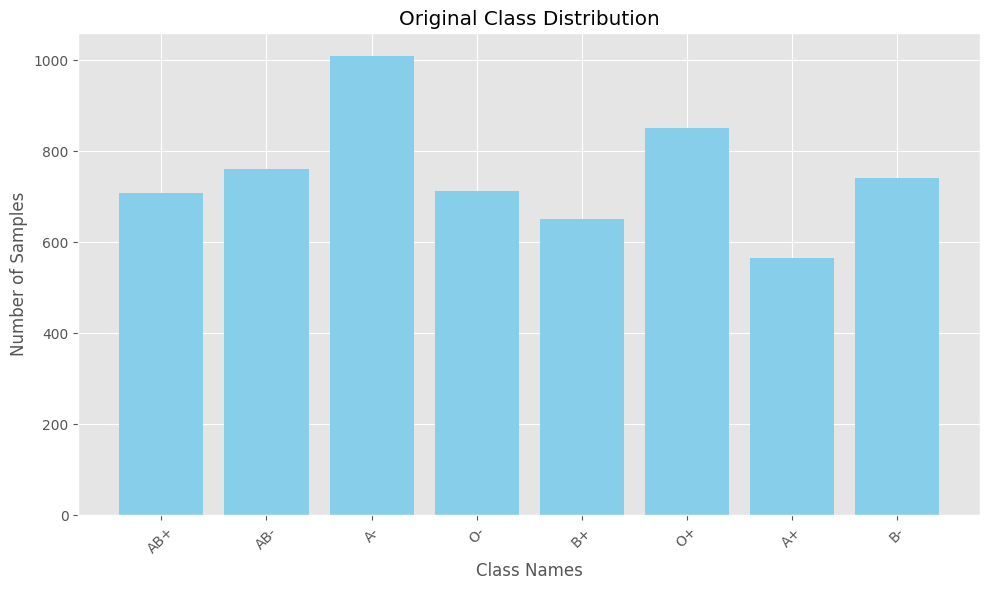

In [15]:
# Calculate class counts
class_counts = Counter()
for _, labels in dataset.unbatch():
    class_counts[int(labels.numpy())] += 1

print("Class Distribution:")
for i, count in class_counts.items():
    print(f"{class_names[i]}: {count}")

# Plot distribution
def plot_class_distribution(class_names, class_counts, title='Class Distribution'):
    classes = [class_names[i] for i in class_counts.keys()]
    counts = [class_counts[i] for i in class_counts.keys()]

    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Class Names')
    plt.ylabel('Number of Samples')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_class_distribution(class_names, class_counts, title='Original Class Distribution')

### Balance the Dataset

Target samples per class: 1009



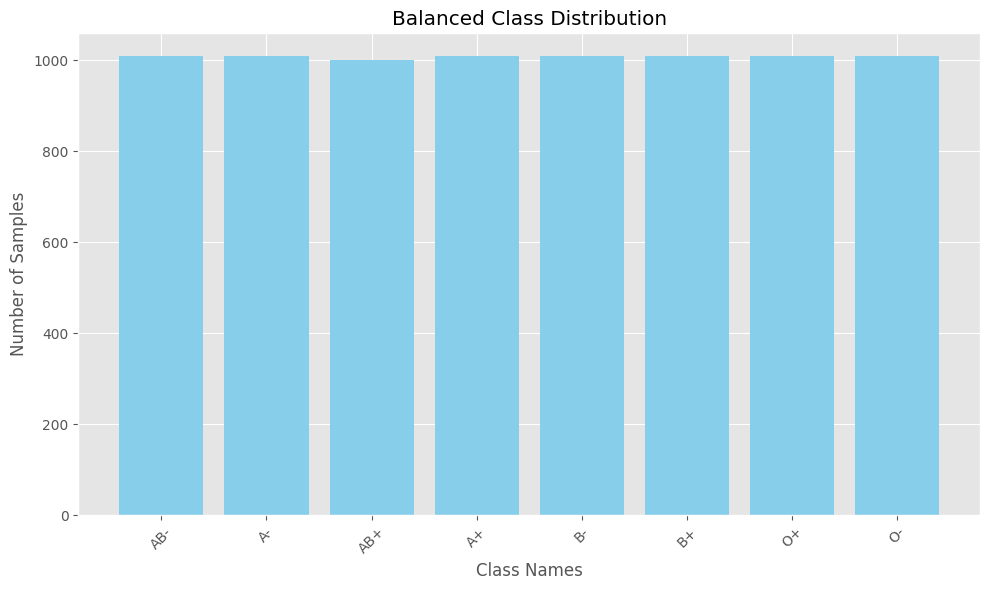


Total balanced dataset size: 8064


In [17]:
max_count = max(class_counts.values())
print(f"Target samples per class: {max_count}\n")

def oversample_class(class_id, count, max_count):
    unbatched_dataset = dataset.unbatch()
    class_dataset = unbatched_dataset.filter(lambda img, lbl: tf.equal(lbl, class_id))
    repeat_factor = max_count // count + (max_count % count > 0)
    return class_dataset.repeat(repeat_factor).take(max_count)

# Create balanced datasets for each class
balanced_datasets = []
for class_id, count in class_counts.items():
    balanced_datasets.append(oversample_class(class_id, count, max_count))

# Merge and batch
balanced_dataset = tf.data.Dataset.sample_from_datasets(balanced_datasets)
balanced_dataset = balanced_dataset.batch(BATCH_SIZE, drop_remainder=True)

# Verify new distribution
balanced_dataset_unbatched = balanced_dataset.unbatch()
balanced_class_counts = Counter([int(lbl.numpy()) for _, lbl in balanced_dataset_unbatched])
plot_class_distribution(class_names, balanced_class_counts, title='Balanced Class Distribution')

dataset_size = sum(1 for _ in balanced_dataset.unbatch())
print(f"\nTotal balanced dataset size: {dataset_size}")

### Split Data (Train/Val/Test)

In [18]:
# Unbatch to split
balanced_dataset_unbatched = balanced_dataset.unbatch()

train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)
# Test size is the remainder

train_dataset = balanced_dataset_unbatched.take(train_size)
val_test_dataset = balanced_dataset_unbatched.skip(train_size)
val_dataset = val_test_dataset.take(val_size)
test_dataset = val_test_dataset.skip(val_size)

# Batch the datasets
train_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=True)
val_dataset = val_dataset.batch(BATCH_SIZE, drop_remainder=True)
test_dataset = test_dataset.batch(BATCH_SIZE, drop_remainder=True)

print(f"Training batches: {len(list(train_dataset))}")
print(f"Validation batches: {len(list(val_dataset))}")
print(f"Testing batches: {len(list(test_dataset))}")

Training batches: 176
Validation batches: 50
Testing batches: 25


### Define Model Architecture

In [19]:
def create_high_accuracy_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.4),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.4),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.4),

        Conv2D(512, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.5),

        Flatten(),
        Dense(1024, activation='relu'),
        Dropout(0.5),

        Dense(len(class_names), activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

high_accuracy_model = create_high_accuracy_model()
high_accuracy_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │         8,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,674,952 (14.02 MB)

 Trainable params: 3,674,952 (14.02 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [20]:
# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

# Training
history_high_acc = high_accuracy_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 94ms/step - accuracy: 0.1296 - loss: 32.7606 - val_accuracy: 0.1244 - val_loss: 2.0800 - learning_rate: 0.0010
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.1420 - loss: 2.0842 - val_accuracy: 0.2025 - val_loss: 2.0522 - learning_rate: 0.0010
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.3226 - loss: 1.7842 - val_accuracy: 0.6212 - val_loss: 1.4631 - learning_rate: 0.0010
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.5314 - loss: 1.2687 - val_accuracy: 0.6756 - val_loss: 1.2788 - learning_rate: 0.0010
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.6034 - loss: 1.0645 - val_accuracy: 0.7525 - val_loss: 1.1525 - learning_rate: 0.0010
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 185ms/step - accuracy: 0.6483 - loss: 0.9465 - val_accuracy: 0.7281 - val_loss: 1.1541 - learning_rate: 0.0010
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.6932 -

In [21]:
high_accuracy_model.save('tensorflow.h5')
print("Model saved as Successfully")

Model saved as Successfully


### Model Evaluation

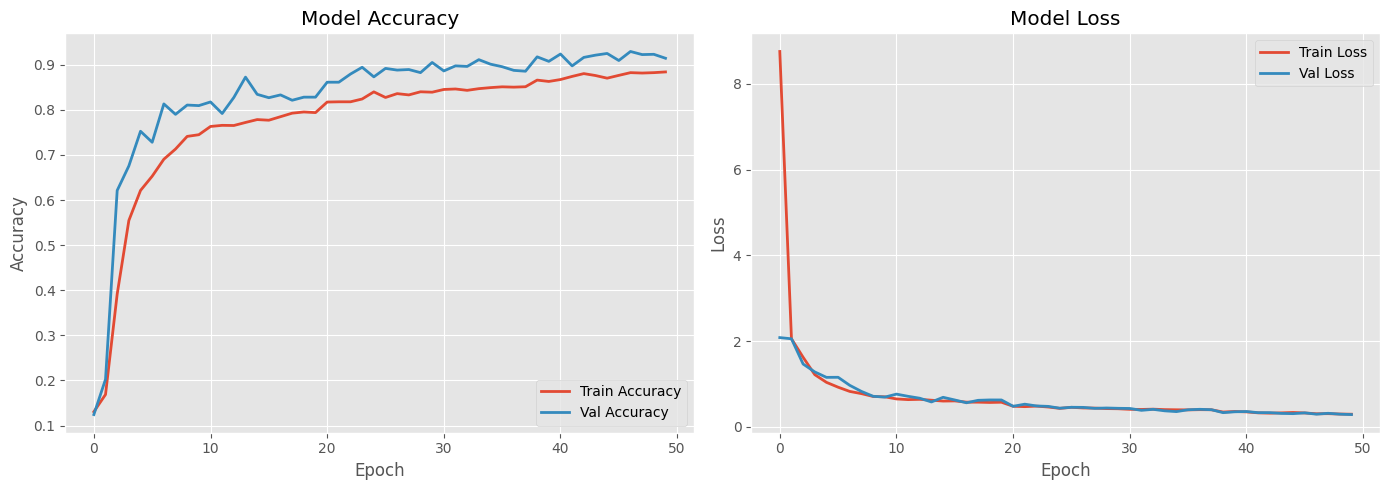

In [22]:
def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy Plot
    axs[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axs[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(loc='lower right')
    axs[0].grid(True)

    # Loss Plot
    axs[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axs[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_high_acc)

In [23]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = high_accuracy_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

          A+       0.99      0.90      0.94        98
          A-       0.87      0.84      0.85        91
         AB+       0.91      0.95      0.93       120
         AB-       0.85      0.98      0.91        96
          B+       0.93      0.91      0.92        90
          B-       0.95      0.96      0.95       113
          O+       0.93      0.84      0.88        99
          O-       0.92      0.97      0.94        93

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



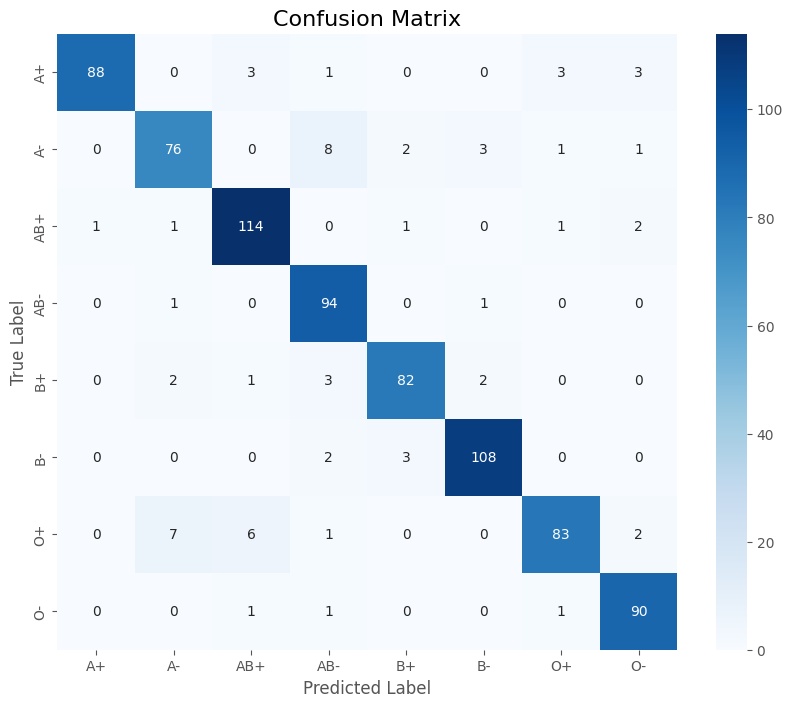

In [24]:
plt.figure(figsize=(10, 8))
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

### Model Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


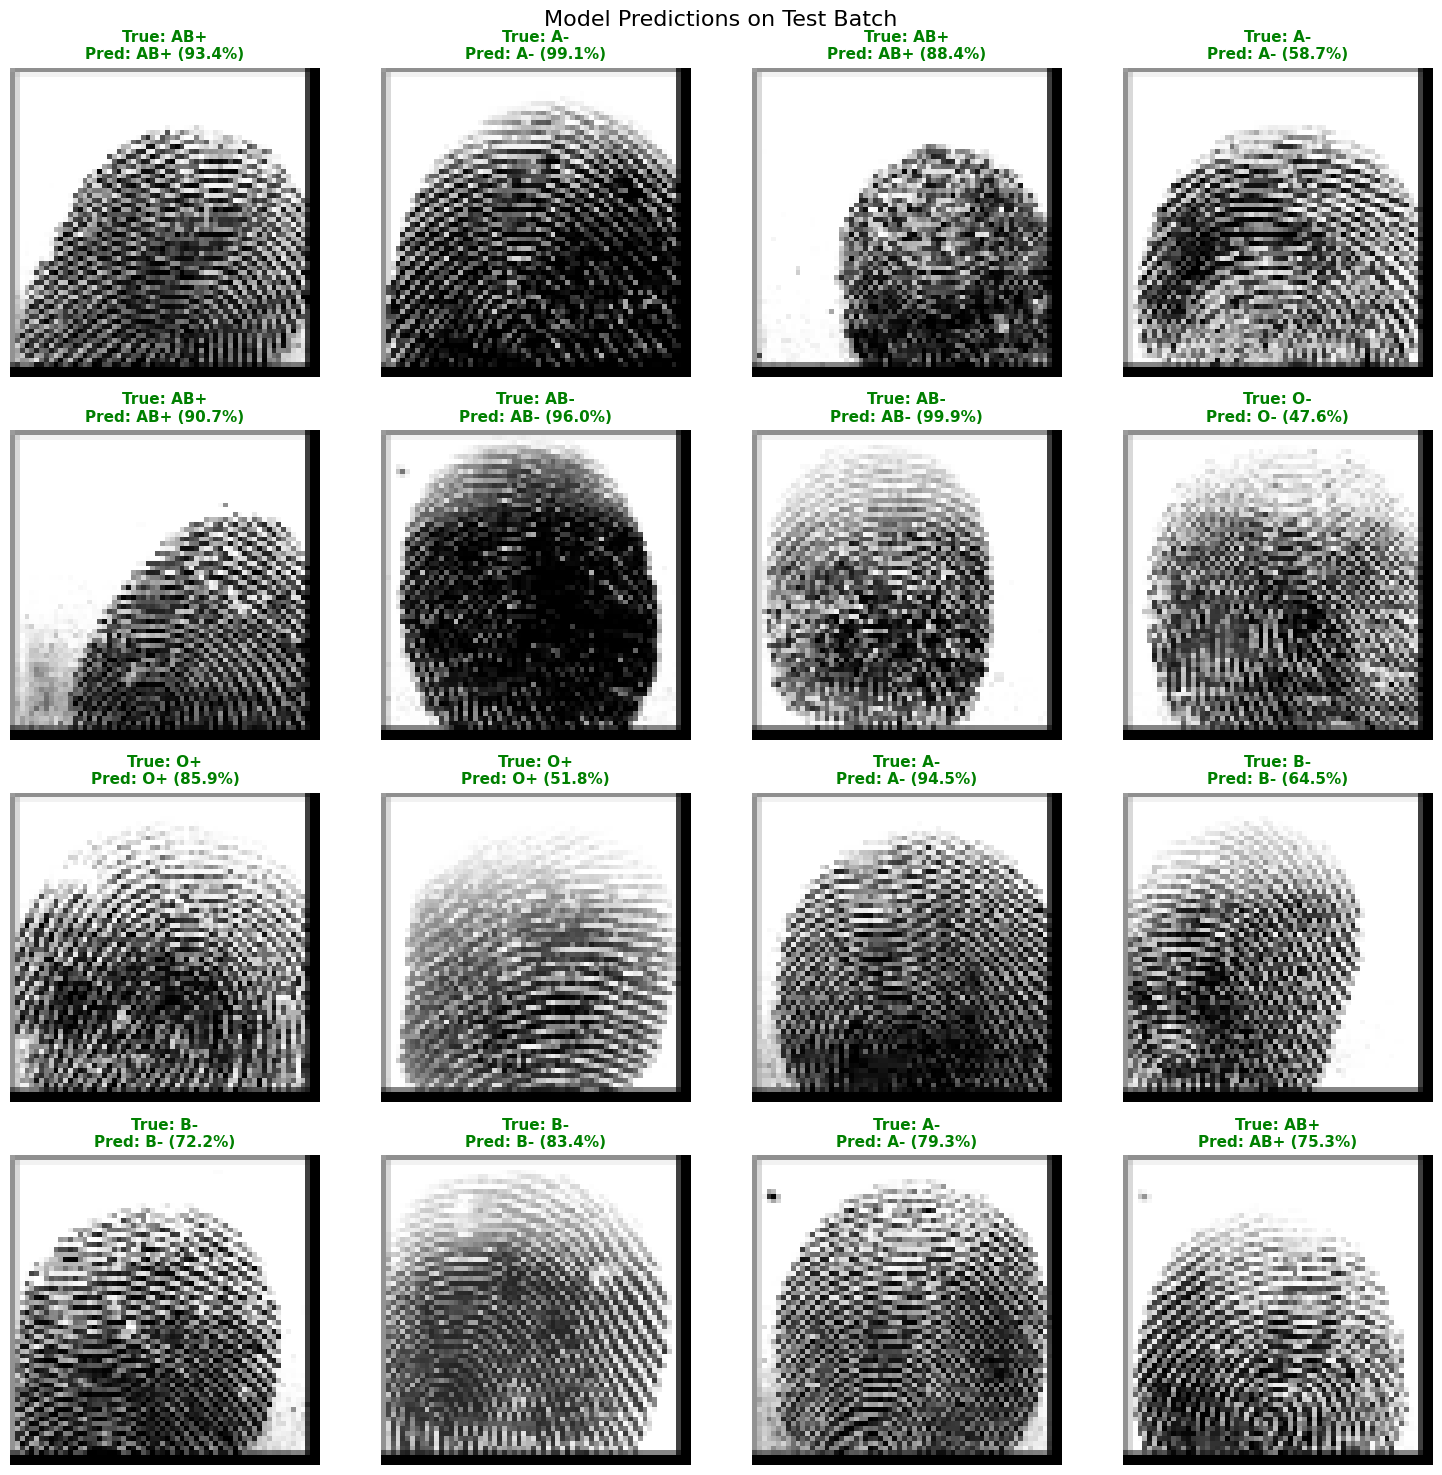

In [25]:
for images, labels in test_dataset.take(1):
    test_images = images.numpy()
    test_labels = labels.numpy()

predictions = high_accuracy_model.predict(test_images)
pred_indices = np.argmax(predictions, axis=1)
confidences = np.max(predictions, axis=1) * 100

num_rows = 4
num_cols = 4
num_images = num_rows * num_cols

plt.figure(figsize=(15, 15))

for i in range(min(num_images, len(test_images))):
    ax = plt.subplot(num_rows, num_cols, i + 1)

    plt.imshow(test_images[i].astype("uint8"))

    true_label = class_names[test_labels[i]]
    pred_label = class_names[pred_indices[i]]
    confidence = confidences[i]

    title_color = 'green' if true_label == pred_label else 'red'

    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
              color=title_color, fontsize=11, fontweight='bold')
    plt.axis('off')

plt.suptitle("Model Predictions on Test Batch", fontsize=16)
plt.tight_layout()
plt.show()